# Model Metrics Comparison
## Precision, Recall, F1 Score, and AUC Analysis

This notebook loads and compares precision, recall, F1 scores, and AUC from all models in the outputs/ directory.

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import re


plt.style.use("seaborn-v0_8-paper")
sns.set_palette("pastel")
plt.rcParams["figure.figsize"] = (10, 10)
plt.rcParams["font.family"] = "Courier New"
plt.rcParams["font.size"] = 20
plt.rcParams["axes.labelsize"] = 20
plt.rcParams["axes.titlesize"] = 20
plt.rcParams["xtick.labelsize"] = 20
plt.rcParams["ytick.labelsize"] = 20
plt.rcParams["legend.fontsize"] = 20
plt.rcParams["figure.dpi"] = 300

## 1. Load Metrics from All Models

In [41]:
def parse_eval_report(filepath):
    """Parse eval_report.txt and extract precision, recall, F1 score, AUC, and support from weighted avg."""
    try:
        with open(filepath, 'r') as f:
            content = f.read()
        
        # Extract weighted avg metrics from classification report table
        # Format: "   weighted avg       0.50      0.50      0.50       447"
        weighted_avg_match = re.search(r'weighted avg\s+([0-9.]+)\s+([0-9.]+)\s+([0-9.]+)\s+([0-9]+)', content)
        
        # Extract AUC
        # Format: "Pairwise Test AUC:      0.7174"
        auc_match = re.search(r'Pairwise Test AUC:\s+([0-9.]+)', content)
        
        if weighted_avg_match:
            return {
                'precision': float(weighted_avg_match.group(1)),
                'recall': float(weighted_avg_match.group(2)),
                'f1': float(weighted_avg_match.group(3)),
                'support': int(weighted_avg_match.group(4)),
                'auc': float(auc_match.group(1)) if auc_match else float('nan')
            }
    except Exception as e:
        print(f"Error parsing {filepath}: {e}")
    
    return None

def load_all_metrics(base_dir='../outputs-final'):
    """Load metrics from all model directories."""
    base_path = Path(base_dir)
    metrics_data = []
    
    for model_dir in base_path.iterdir():
        if not model_dir.is_dir():
            continue
        
        eval_report = model_dir / 'eval_report.txt'
        if eval_report.exists():
            metrics = parse_eval_report(eval_report)
            if metrics:
                metrics['model'] = model_dir.name
                metrics_data.append(metrics)
                print(f"Loaded metrics from {model_dir.name}")
    
    return pd.DataFrame(metrics_data)

# Load all metrics
df = load_all_metrics()
print(f"\nLoaded metrics from {len(df)} models")
df

Loaded metrics from varmail
Loaded metrics from webproxy
Loaded metrics from openfiles
Loaded metrics from copyfiles
Loaded metrics from webserver
Loaded metrics from fileserver
Loaded metrics from mongo

Loaded metrics from 7 models


,precision,recall,f1,support,auc,model
0,0.65,0.65,0.65,347207,0.7174,varmail
1,0.72,0.72,0.72,498761,0.7984,webproxy
2,0.72,0.72,0.72,51200,0.8366,openfiles
3,0.99,0.99,0.99,2397,0.9993,copyfiles
4,0.93,0.93,0.93,473876,0.9838,webserver
5,0.55,0.55,0.55,69073,0.5769,fileserver
6,0.65,0.65,0.65,106503,0.7556,mongo


## 2. Display Summary Statistics

In [42]:
if len(df) == 0:
    print("No models found! Check that eval_report.txt files exist in the outputs directory.")
else:
    print("Summary Statistics:")
    print("=" * 60)
    print(df[['precision', 'recall', 'f1', 'auc']].describe())
    print("\nModels sorted by AUC:")
    print("=" * 60)
    display(df.sort_values('auc', ascending=False))

Summary Statistics:
       precision    recall        f1       auc
count   7.000000  7.000000  7.000000  7.000000
mean    0.744286  0.744286  0.744286  0.809714
std     0.158940  0.158940  0.158940  0.148746
min     0.550000  0.550000  0.550000  0.576900
25%     0.650000  0.650000  0.650000  0.736500
50%     0.720000  0.720000  0.720000  0.798400
75%     0.825000  0.825000  0.825000  0.910200
max     0.990000  0.990000  0.990000  0.999300

Models sorted by AUC:


,precision,recall,f1,support,auc,model
3,0.99,0.99,0.99,2397,0.9993,copyfiles
4,0.93,0.93,0.93,473876,0.9838,webserver
2,0.72,0.72,0.72,51200,0.8366,openfiles
1,0.72,0.72,0.72,498761,0.7984,webproxy
6,0.65,0.65,0.65,106503,0.7556,mongo
0,0.65,0.65,0.65,347207,0.7174,varmail
5,0.55,0.55,0.55,69073,0.5769,fileserver


## 3. Create Grouped Bar Chart

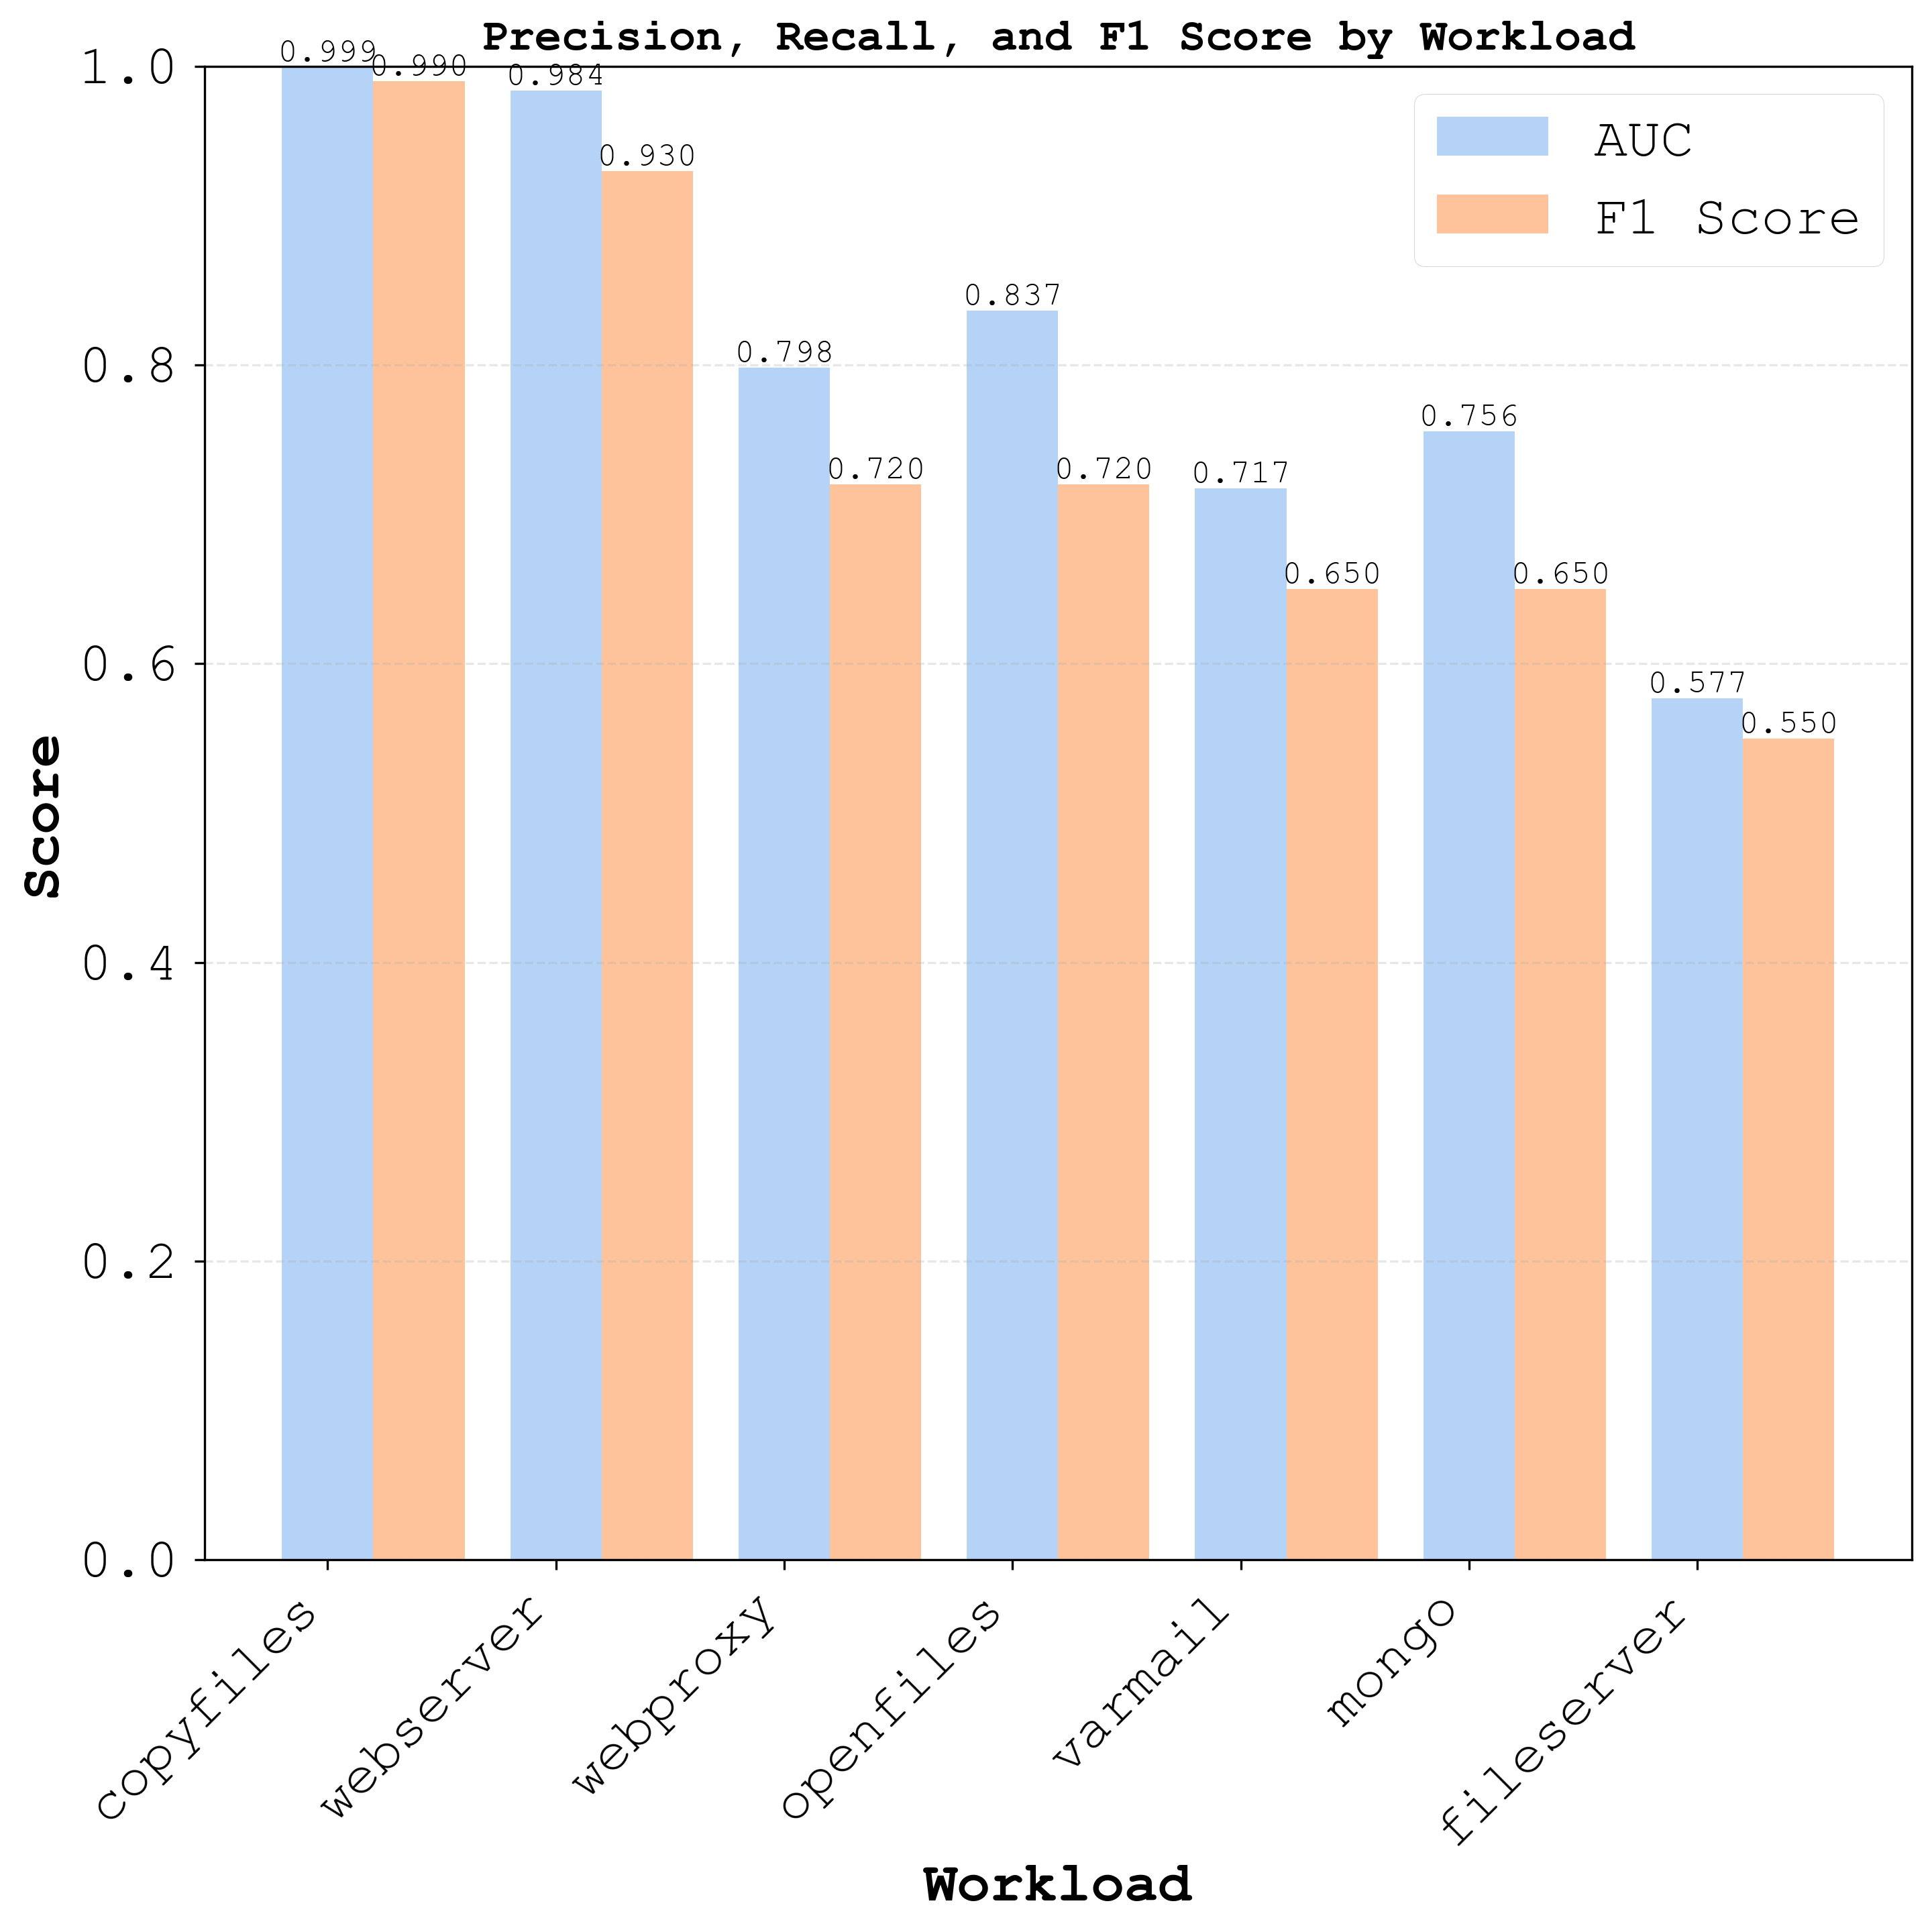

In [43]:
if len(df) == 0:
    print("No data to plot!")
else:
    df_sorted = df.sort_values('f1', ascending=False)

    fig, ax = plt.subplots(figsize=(10, 10))

    x = np.arange(len(df_sorted))
    width = 0.4

    bars0 = ax.bar(x, df_sorted["auc"], width, label="AUC", alpha=0.8)
    bars1 = ax.bar(x + width, df_sorted['f1'], width, label='F1 Score', alpha=0.8)

    ax.set_xlabel('Workload', fontweight='bold')
    ax.set_ylabel('Score', fontweight='bold')
    ax.set_title('Precision, Recall, and F1 Score by Workload', fontweight='bold', fontsize=16)
    ax.set_xticks(x)
    ax.set_xticklabels(df_sorted['model'], rotation=45, ha='right')
    ax.legend(loc='upper right')
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    ax.set_ylim(0, 1.0)

    def add_value_labels(bars):
        for bar in bars:
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height,
                    f'{height:.3f}',
                    ha='center', va='bottom', fontsize=12)

    add_value_labels(bars0)
    add_value_labels(bars1)

    plt.tight_layout()
    plt.show()

## 4. Support vs F1 Score Trend

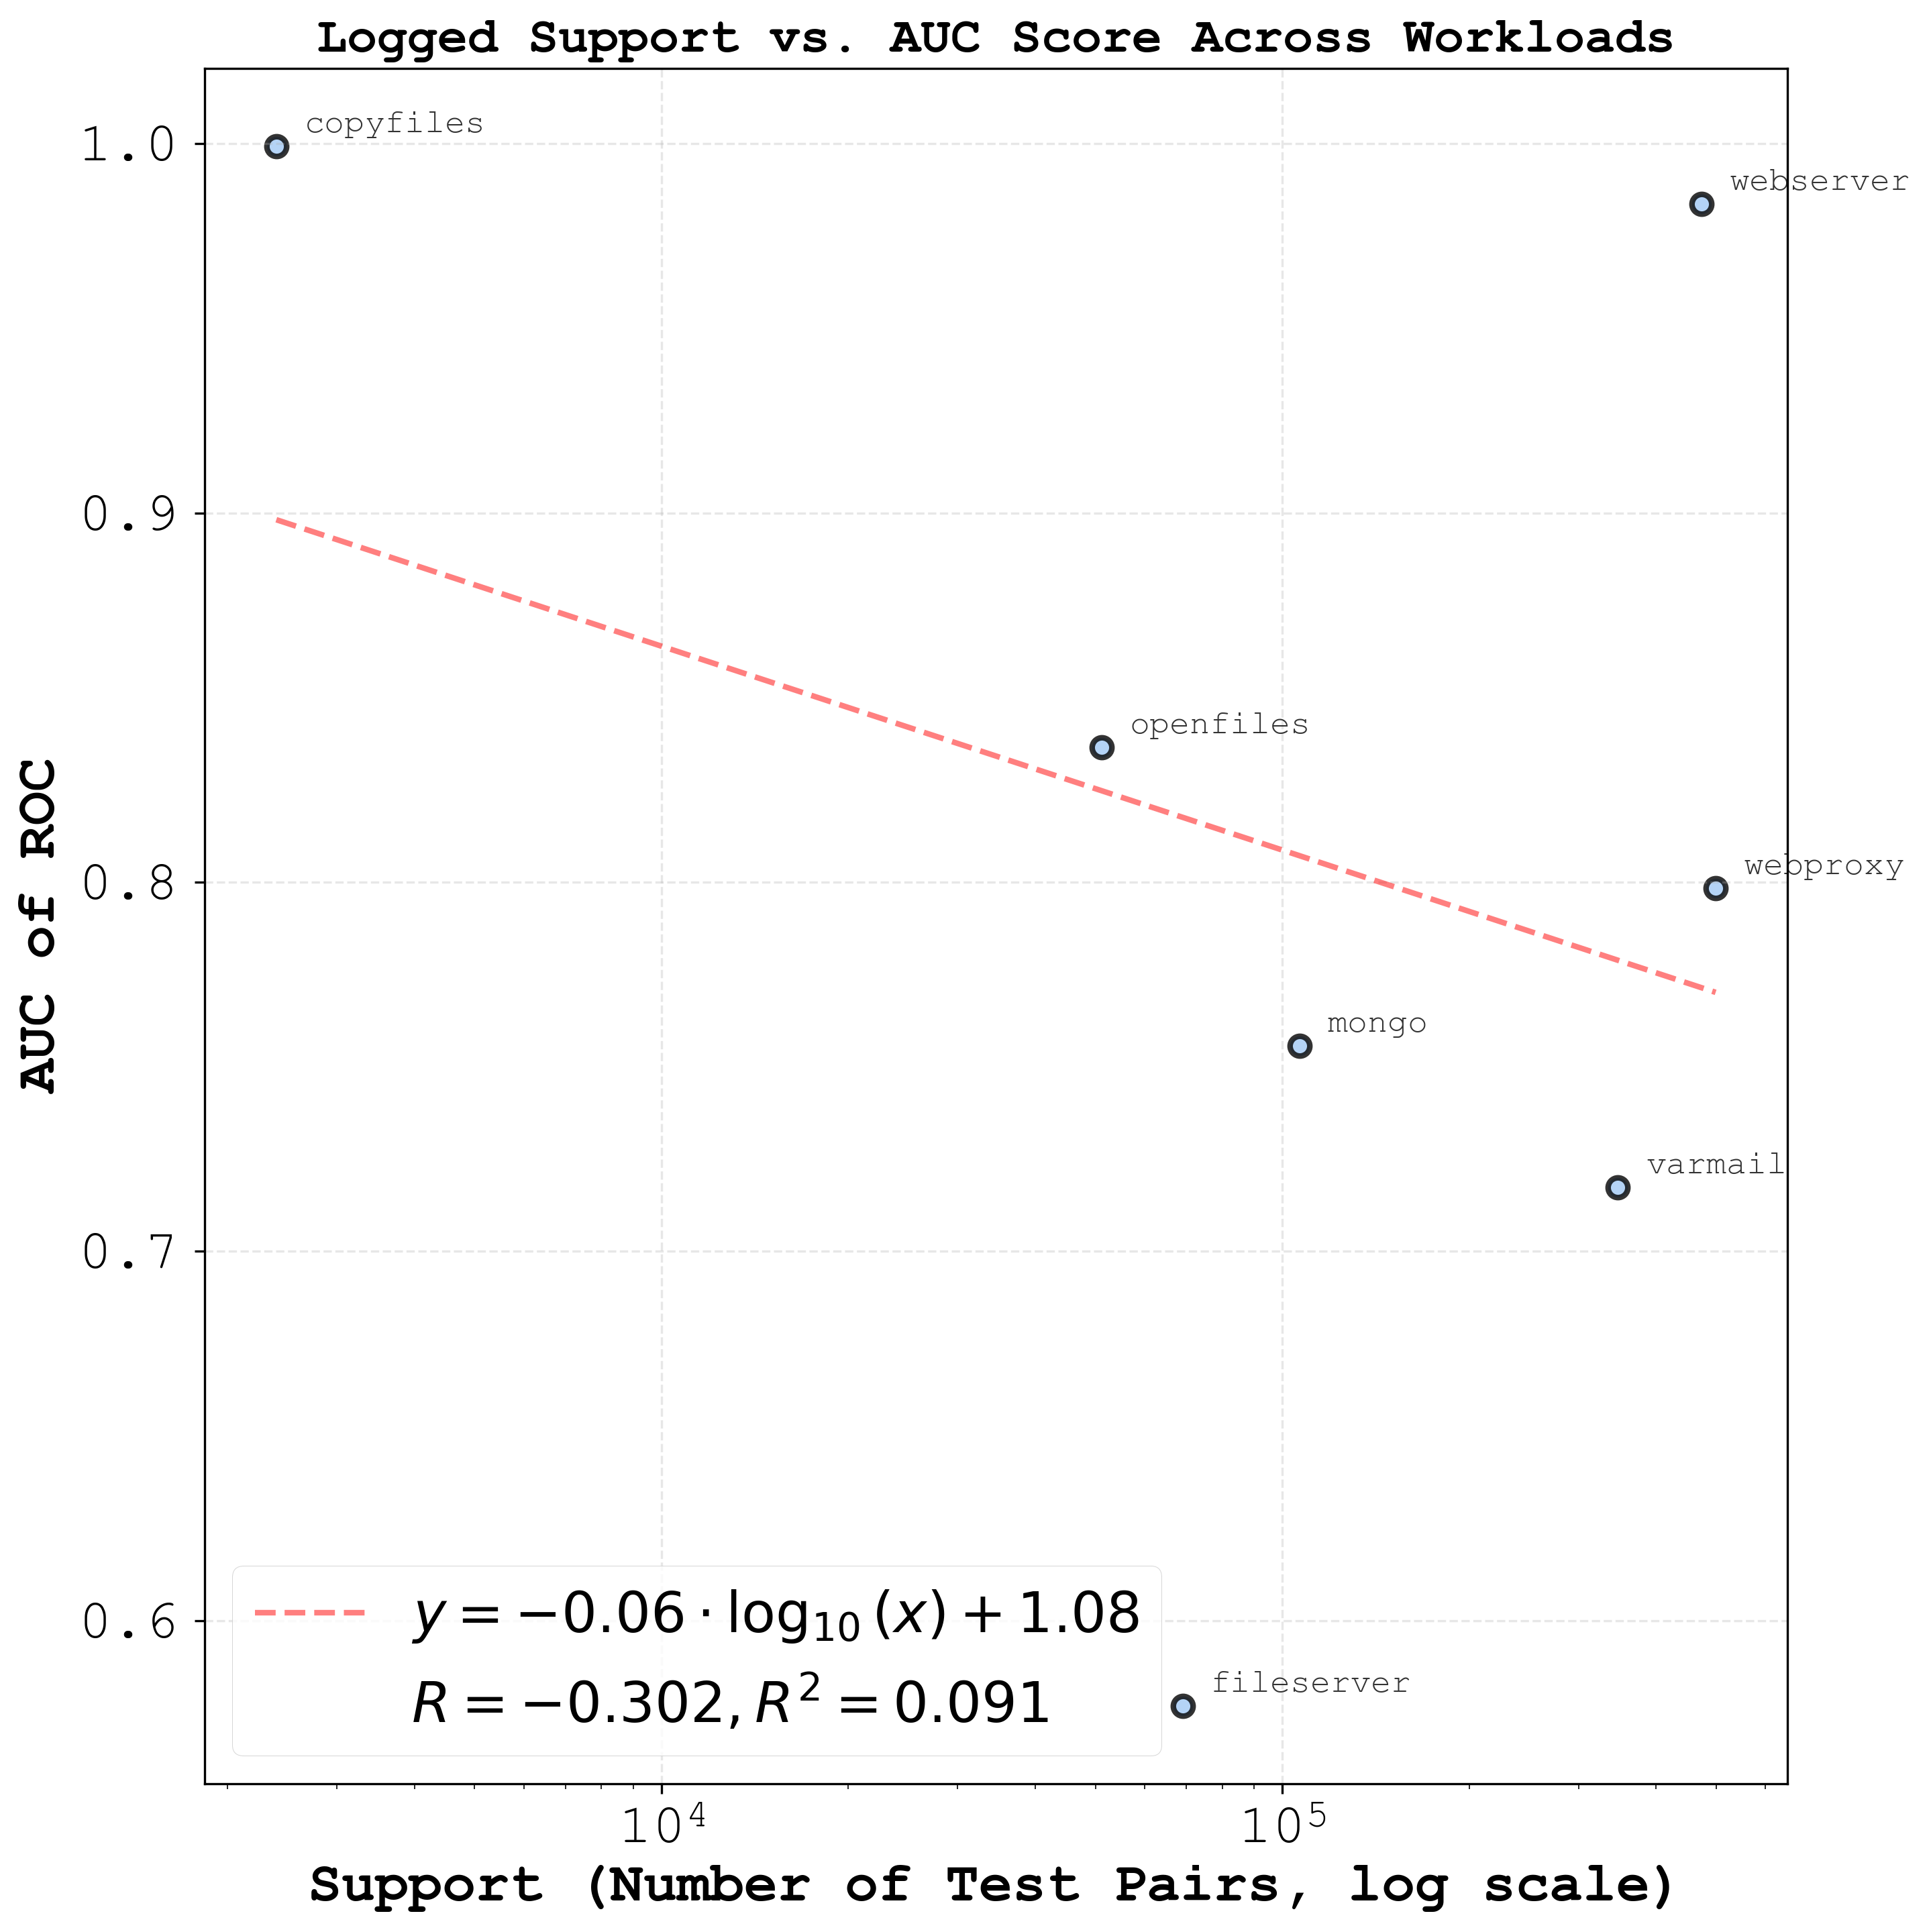

In [44]:
fig, ax = plt.subplots(figsize=(10, 10))

scatter = ax.scatter(df['support'], df['auc'], s=50, alpha=0.8, edgecolors='black', linewidth=2)

for idx, row in df.iterrows():
    ax.annotate(row['model'], 
                (row['support'], row['auc']),
                xytext=(10, 5), 
                textcoords='offset points',
                fontsize=12,
                alpha=0.8)

log_support = np.log10(df['support'])
z = np.polyfit(log_support, df['auc'], 1)
p = np.poly1d(z)
support_sorted = np.sort(df['support'])
log_support_sorted = np.log10(support_sorted)

predicted = p(log_support)
r = np.corrcoef(log_support, df['auc'])[0, 1]
r_squared = r**2

ax.plot(support_sorted, p(log_support_sorted), "r--", alpha=0.5, linewidth=2, 
        label=rf'$y = {z[0]:.2f} \cdot \log_{{10}}(x) + {z[1]:.2f}$')

ax.plot([], [], ' ', label=rf'$R = {r:.3f}, R^2 = {r_squared:.3f}$')

ax.set_xlabel('Support (Number of Test Pairs, log scale)', fontweight='bold')
ax.set_ylabel('AUC of ROC', fontweight='bold')
ax.set_title('Logged Support vs. AUC Score Across Workloads', fontweight='bold', fontsize=18)
ax.grid(True, alpha=0.3, linestyle='--')
ax.legend(loc='best')

ax.set_xscale('log')

plt.tight_layout()
plt.show()


## 5. Residual Plot

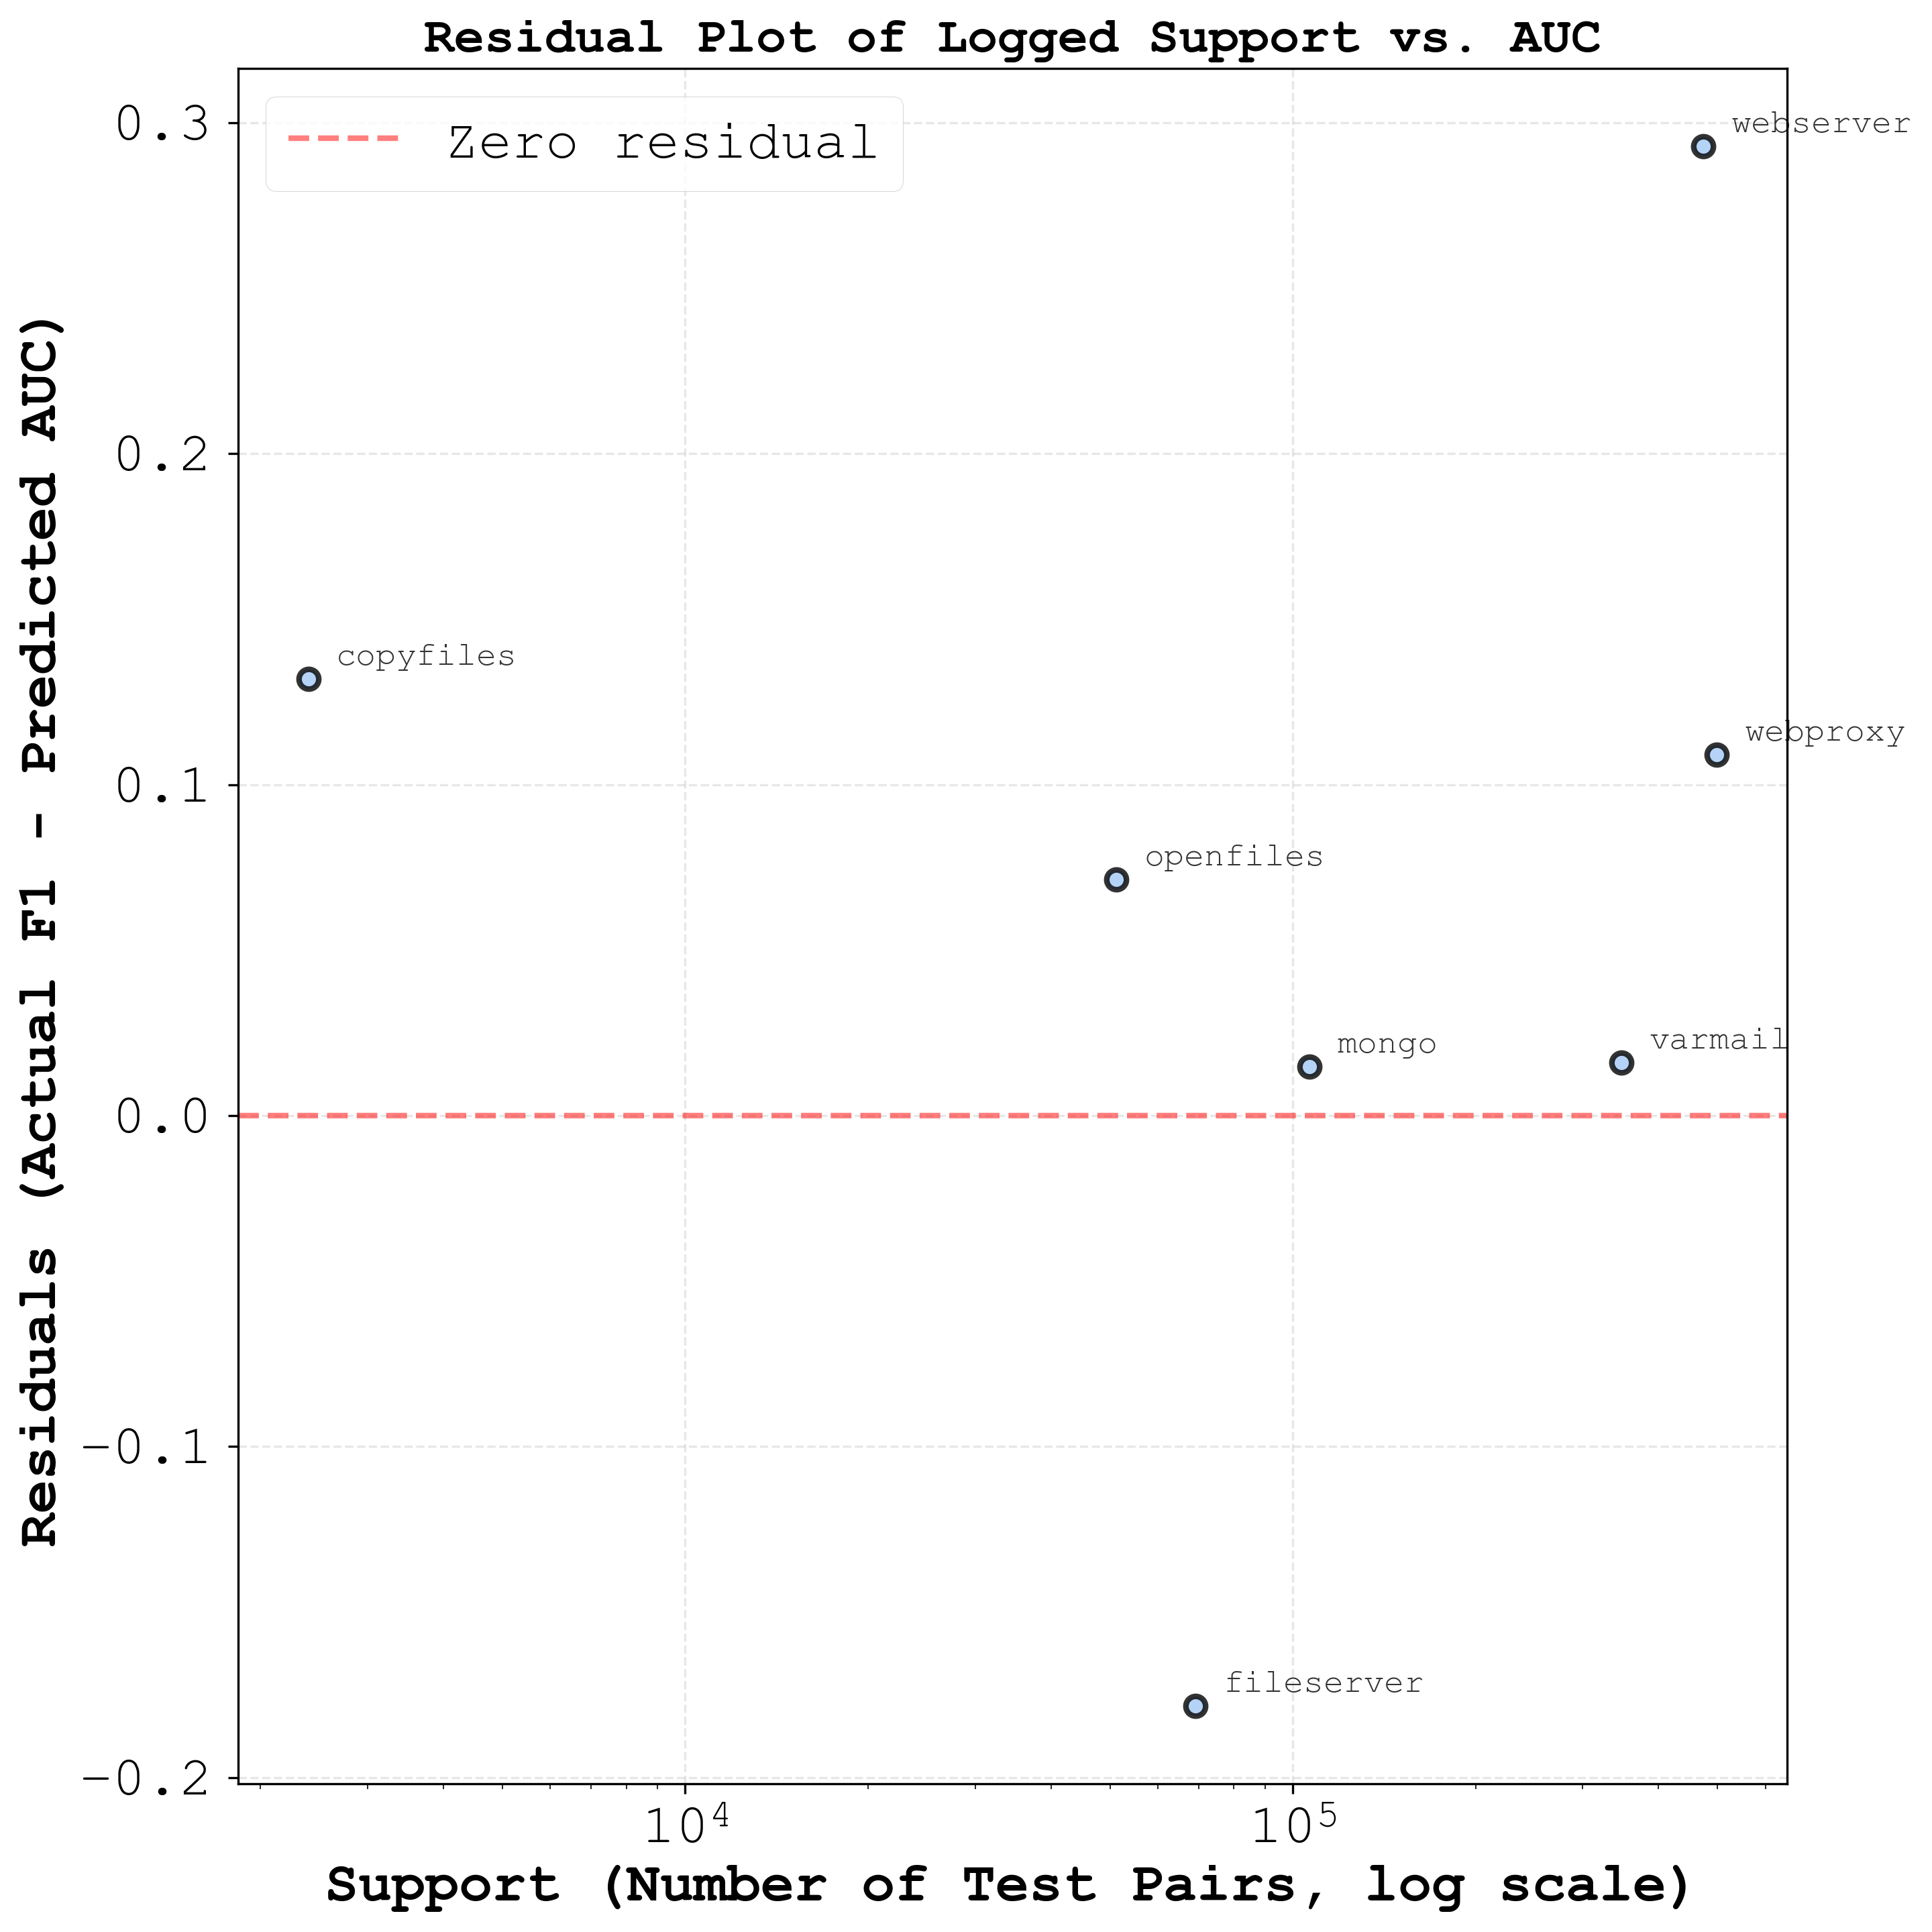

\nResidual Statistics:
Mean residual: 0.065429
Std deviation: 0.142881
Max positive residual: 0.292831 (webserver)
Max negative residual: -0.178297 (fileserver)


In [45]:
if len(df) == 0:
    print("No data to plot!")
else:
    log_support = np.log10(df['support'])
    z = np.polyfit(log_support, df['f1'], 1)
    p = np.poly1d(z)
    predicted = p(log_support)
    residuals = df['auc'] - predicted
    
    fig, ax = plt.subplots(figsize=(10, 10))
    
    ax.scatter(df['support'], residuals, s=50, alpha=0.8, edgecolors='black', linewidth=2)
    
    ax.axhline(y=0, color='r', linestyle='--', linewidth=2, alpha=0.5, label='Zero residual')
    
    for idx, row in df.iterrows():
        ax.annotate(row['model'], 
                   (row['support'], residuals[idx]),
                   xytext=(10, 5), 
                   textcoords='offset points',
                   fontsize=12,
                   alpha=0.8)
    
    ax.set_xlabel('Support (Number of Test Pairs, log scale)', fontweight='bold')
    ax.set_ylabel('Residuals (Actual F1 - Predicted AUC)', fontweight='bold')
    ax.set_title('Residual Plot of Logged Support vs. AUC', fontweight='bold', fontsize=18)
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.legend(loc='best')
    
    ax.set_xscale('log')
    
    plt.tight_layout()
    plt.show()
    
    print(f"\\nResidual Statistics:")
    print(f"Mean residual: {residuals.mean():.6f}")
    print(f"Std deviation: {residuals.std():.6f}")
    print(f"Max positive residual: {residuals.max():.6f} ({df.loc[residuals.idxmax(), 'model']})")
    print(f"Max negative residual: {residuals.min():.6f} ({df.loc[residuals.idxmin(), 'model']})")